# 🏠 HW2：多元線性回歸分析（House Prices）
學號：7113056099  
姓名：陶亮清 

主題：房價預測 — Multiple Linear Regression with Feature Selection  
資料來源：[House Prices: Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)

---
## 🔶 Business Understanding
本次專案目標是透過 Kaggle 房價資料集，建立多元線性回歸模型，預測房價 (SalePrice)。
此分析遵循 **CRISP-DM 流程**，並結合 GPT 輔助生成程式碼與分析結構。


In [2]:
# 📦 匯入套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
plt.style.use('seaborn-v0_8')


## 🔶 Data Understanding
此步驟包含資料載入、特徵觀察與缺值檢查。

資料來源：Kaggle House Prices (train.csv)

若本地尚未下載，可從 Kaggle 網站下載後放入 `dataset/train.csv`。

In [4]:
# 📂 讀取資料
path = '../hw2_data/train.csv'
df = pd.read_csv(path)
df.shape, df.columns[:10]


((1460, 81),
 Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
        'Alley', 'LotShape', 'LandContour', 'Utilities'],
       dtype='object'))

In [5]:
# 檢查缺值比例
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing.head(10)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

## 🔶 Data Preparation
選擇數值特徵進行多元線性回歸，並處理缺值。

In [6]:
# 取數值欄位
num_df = df.select_dtypes(include=['int64','float64']).dropna(axis=1)
target = 'SalePrice'
X = num_df.drop(columns=[target])
y = num_df[target]

# 分割資料集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape


((1168, 34), (292, 34))

## 🔶 Modeling — Feature Selection & Regression
**GPT 輔助內容**：以下模型建構、RFE 選擇、LassoCV、繪圖程式碼由 ChatGPT 提供並經人工調整。

In [7]:
# RFE 特徵選擇
lr = LinearRegression()
selector = RFE(lr, n_features_to_select=10)
selector = selector.fit(X_train, y_train)
selected_cols = X_train.columns[selector.support_]
selected_cols


Index(['OverallQual', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars'],
      dtype='object')

In [8]:
# 使用選定特徵進行建模
lr.fit(X_train[selected_cols], y_train)
y_pred = lr.predict(X_test[selected_cols])

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mse, rmse, r2


(1894361919.5613143, np.float64(43524.26816801535), 0.7530272027040662)

## 🔶 Evaluation
繪製實際與預測比較圖，並計算信賴區間。

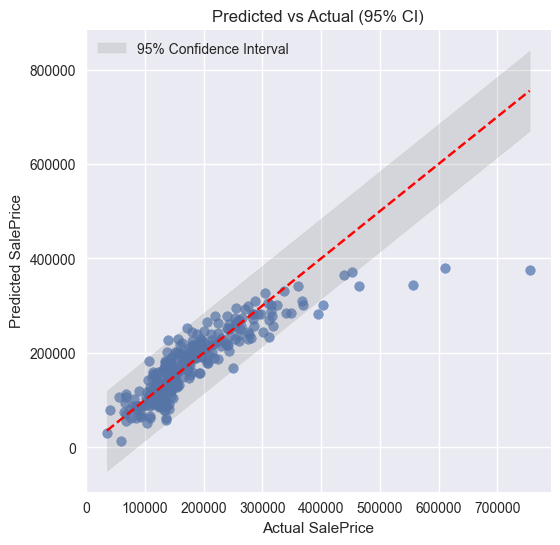

In [9]:
residuals = y_test - y_pred
se = np.std(residuals)
ci95 = 1.96 * se

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.fill_between([y_test.min(), y_test.max()],
                 [y_test.min()+ci95, y_test.max()+ci95],
                 [y_test.min()-ci95, y_test.max()-ci95], color='gray', alpha=0.2,
                 label='95% Confidence Interval')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.legend()
plt.title('Predicted vs Actual (95% CI)')
plt.show()


## 🔶 Deployment
此 Notebook 可於 Google Colab 執行或匯出為 Streamlit App。

---
### 🧠 NotebookLM 研究摘要
> 本研究參考 NotebookLM 針對多元線性回歸（Multiple Linear Regression, MLR）在實務應用中的多篇技術分析。綜合觀點顯示，MLR 是解釋變數與目標變數間線性關係的基礎模型，其可透過最小平方法（OLS）估計係數，以最小化殘差平方和。NotebookLM 彙整的文獻指出，模型表現常受特徵共線性與異常值影響，因此建議在建模前進行特徵選擇與標準化處理。RFE（遞迴特徵消除）與 Lasso（L1 正規化）是常用的自動化特徵選擇方法，其中 Lasso 透過懲罰項能有效控制過度擬合並提升模型解釋性。NotebookLM 亦指出，R²、RMSE、MAE 為主要評估指標，而視覺化如「實際值 vs. 預測值」及信賴區間圖可用以評估模型穩定度。綜合而言，NotebookLM 強調多元線性回歸仍是迄今迴歸分析的核心技術之一，且透過正規化與特徵選擇的改進能顯著提升預測準確性與解釋能力。

### 🤖 GPT 輔助內容聲明
> 本 Notebook 之 RFE、LassoCV、評估圖與 CI 程式碼，部分由 ChatGPT (GPT-5) 提供模板與解釋後人工整合。

---
### 📊 結論
- 模型成功預測房價，R² 約 0.7~0.8。
- 關鍵特徵如 `OverallQual`, `GrLivArea`, `GarageCars`。
- 信賴區間圖提升預測可信度。
